In [10]:
# model_training.ipynb
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration
BALANCED_PATH = '../data/balanced/mitral_valve'
OUTPUT_PATH = '../exported_models/mitral_classifier'
os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, 'checkpoints'), exist_ok=True)

In [11]:

class HeartSoundDataGenerator:
    """Custom data generator for heart sound spectrograms"""
    
    def __init__(self, data_dir, df, batch_size=32, target_size=(224, 224), 
                 use_augmentation=False):
        self.data_dir = data_dir
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.target_size = target_size
        self.use_augmentation = use_augmentation
        self.classes = ['normal', 'rhd']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        
        # Parameters for mel spectrogram
        self.n_mels = 128
        self.n_fft = 2048
        self.hop_length = 512
        
    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_df = self.df[idx * self.batch_size:(idx + 1) * self.batch_size]
        
        X_batch = []
        y_batch = []
        
        for _, row in batch_df.iterrows():
            patient_id = row['patient_id']
            label = row['label']
            
            # Try different paths
            file_path = None
            
            # Check in main balanced directory
            main_path = os.path.join(self.data_dir, label, f"{patient_id}.wav")
            if os.path.exists(main_path):
                file_path = main_path
            else:
                # Check in augmented directory
                aug_path = os.path.join(self.data_dir, 'augmented', label, f"{patient_id}.wav")
                if os.path.exists(aug_path):
                    file_path = aug_path
                else:
                    # Try to find any file starting with patient_id
                    aug_dir = os.path.join(self.data_dir, 'augmented', label)
                    if os.path.exists(aug_dir):
                        for f in os.listdir(aug_dir):
                            if f.startswith(str(patient_id)):
                                file_path = os.path.join(aug_dir, f)
                                break
            
            if file_path is None:
                print(f"Warning: File not found for {patient_id}")
                placeholder = np.zeros((*self.target_size, 3))
                X_batch.append(placeholder)
                y_batch.append(0)
                continue
            
            try:
                # Load audio (already bandpass filtered from preprocessing)
                signal, fs = librosa.load(file_path, sr=4000)
                
                # Generate mel spectrogram
                mel_spec = librosa.feature.melspectrogram(
                    y=signal, 
                    sr=fs,
                    n_mels=self.n_mels,
                    n_fft=self.n_fft,
                    hop_length=self.hop_length,
                    fmin=20,    # Keep within bandpass range
                    fmax=400
                )
                
                # Log compression
                mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
                
                # Normalize to [0, 1]
                mel_spec = (mel_spec - mel_spec.min()) / (mel_spec.max() - mel_spec.min() + 1e-8)
                
                # Resize to target size
                mel_spec = tf.image.resize(
                    mel_spec[..., np.newaxis], 
                    self.target_size
                ).numpy()
                
                # Convert to 3-channel for MobileNetV2
                mel_spec = np.repeat(mel_spec, 3, axis=-1)
                
                X_batch.append(mel_spec)
                y_batch.append(self.class_to_idx[label])
                
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                placeholder = np.zeros((*self.target_size, 3))
                X_batch.append(placeholder)
                y_batch.append(0)
        
        # Preprocess for MobileNetV2
        X_batch = np.array(X_batch)
        X_batch = preprocess_input(X_batch)
        y_batch = tf.keras.utils.to_categorical(y_batch, num_classes=2)
        
        return X_batch, y_batch

In [12]:


def create_mobilenetv2_model(input_shape=(224, 224, 3), num_classes=2):
    """Create MobileNetV2 model for heart sound classification"""
    
    # Base model
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False
    
    # Custom head with regularization
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
     
    
    model = models.Model(inputs=base_model.input, outputs=outputs)
    
    return model

In [13]:
def create_data_splits():
    """Create train/val/test splits from combined data"""
    
    # Load combined data
    combined_df = pd.read_csv(os.path.join(BALANCED_PATH, 'combined_summary.csv'))
    
    # Separate original and augmented
    original_df = combined_df[~combined_df['patient_id'].astype(str).str.contains('_', na=False)].copy()
    augmented_df = combined_df[combined_df['patient_id'].astype(str).str.contains('_', na=False)].copy()
    
    print(f"Original samples: {len(original_df)}")
    print(f"Augmented samples: {len(augmented_df)}")
    
    # Split original patients stratified by label
    patients = original_df['patient_id'].unique()
    labels = []
    for patient in patients:
        label = original_df[original_df['patient_id'] == patient]['label'].iloc[0]
        labels.append(label)
    
    # First split: 70% train, 30% test
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(sss.split(patients, labels))
    train_patients = patients[train_idx]
    test_patients = patients[test_idx]
    
    # Split test into validation and test (50/50)
    test_labels = [labels[i] for i in test_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
    val_idx, test_final_idx = next(sss2.split(test_patients, test_labels))
    val_patients = test_patients[val_idx]
    test_patients = test_patients[test_final_idx]
    
    # Create DataFrames
    train_df = original_df[original_df['patient_id'].isin(train_patients)]
    val_df = original_df[original_df['patient_id'].isin(val_patients)]
    test_df = original_df[original_df['patient_id'].isin(test_patients)]
    
    # Add augmented data to training
    train_df = pd.concat([train_df, augmented_df], ignore_index=True)
    
    # Shuffle training data
    train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples: {len(val_df)}")
    print(f"Test samples: {len(test_df)}")
    
    print("\nTrain distribution:")
    print(train_df['label'].value_counts())
    print("\nVal distribution:")
    print(val_df['label'].value_counts())
    print("\nTest distribution:")
    print(test_df['label'].value_counts())
    
    return train_df, val_df, test_df


In [14]:

def train_model(model, train_gen, val_gen, epochs=50):
    """Train the model with class weights"""
    
    # Calculate class weights for imbalance
    train_labels = train_gen.df['label'].values
    class_counts = np.bincount([train_gen.class_to_idx[l] for l in train_labels])
    total = len(train_labels)
    class_weights = {i: total / (len(class_counts) * count) for i, count in enumerate(class_counts)}
    print(f"Class weights: {class_weights}")
    
    # Callbacks
    checkpoint = callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_PATH, 'checkpoints', 'best_model.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    
    early_stopping = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    
    # Train
    history = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=val_gen,
        class_weight=class_weights,
        callbacks=[checkpoint, early_stopping, reduce_lr],
        verbose=1
    )
    
    return history

In [15]:


def plot_training_history(history):
    """Plot training history"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Loss
    axes[0, 1].plot(history.history['loss'], label='Train', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # AUC
    if 'auc' in history.history:
        axes[1, 0].plot(history.history['auc'], label='Train', linewidth=2)
        axes[1, 0].plot(history.history['val_auc'], label='Validation', linewidth=2)
        axes[1, 0].set_title('Model AUC', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('AUC')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
    # Learning rate
    if 'lr' in history.history:
        axes[1, 1].plot(history.history['lr'], linewidth=2)
        axes[1, 1].set_title('Learning Rate', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('LR')
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [16]:


def evaluate_model(model, test_gen, test_df):
    """Evaluate model on test set"""
    
    # Get predictions
    y_true = []
    y_pred = []
    patient_ids = []
    
    for batch in range(len(test_gen)):
        X_batch, y_batch = test_gen[batch]
        pred_batch = model.predict(X_batch, verbose=0)
        
        start_idx = batch * test_gen.batch_size
        end_idx = min(start_idx + test_gen.batch_size, len(test_gen.df))
        batch_patients = test_gen.df.iloc[start_idx:end_idx]['patient_id'].values
        
        y_true.extend(np.argmax(y_batch, axis=1))
        y_pred.extend(pred_batch[:, 1])  # Probability for class 1 (RHD)
        patient_ids.extend(batch_patients)
    
    y_true = np.array(y_true)
    y_pred_proba = np.array(y_pred)
    y_pred_class = (y_pred_proba > 0.5).astype(int)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred_class)
    precision = precision_score(y_true, y_pred_class, average='binary')
    recall = recall_score(y_true, y_pred_class, average='binary')
    f1 = f1_score(y_true, y_pred_class, average='binary')
    auc = roc_auc_score(y_true, y_pred_proba)
    
    
    print("TEST RESULTS")

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC:       {auc:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred_class, 
                               target_names=['Normal', 'RHD']))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred_class)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confusion matrix as heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Normal', 'RHD'],
                yticklabels=['Normal', 'RHD'])
    axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})', linewidth=2)
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'evaluation_results.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Create results DataFrame
    results_df = pd.DataFrame({
        'patient_id': patient_ids[:len(y_true)],
        'true_label': y_true,
        'pred_proba_rhd': y_pred_proba,
        'pred_label': y_pred_class
    })
    results_df['true_label_name'] = results_df['true_label'].map({0: 'Normal', 1: 'RHD'})
    results_df['pred_label_name'] = results_df['pred_label'].map({0: 'Normal', 1: 'RHD'})
    results_df['correct'] = results_df['true_label'] == results_df['pred_label']
    
    # Show misclassified examples
    misclassified = results_df[~results_df['correct']]
    if len(misclassified) > 0:
        print(f"\nMisclassified samples: {len(misclassified)}")
        print(misclassified[['patient_id', 'true_label_name', 'pred_label_name', 'pred_proba_rhd']].head(10))
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'confusion_matrix': cm,
        'results_df': results_df
    }


HEART SOUND CLASSIFICATION - OPTIMIZED FEATURE EXTRACTION

1. Creating data splits...
Original samples: 852
Augmented samples: 4260

Train samples: 4862
Val samples: 122
Test samples: 128

2. Extracting features from audio...
  This may take a few minutes for 4862 samples...
  Processing 4862 files...


  Extracting features: 100%|██████████| 4862/4862 [01:20<00:00, 60.36it/s]


  ✓ Training features: 4862 samples, 51 features
  Processing 122 files...


  Extracting features: 100%|██████████| 122/122 [00:01<00:00, 72.13it/s]


  ✓ Validation features: 122 samples
  Processing 128 files...


  Extracting features: 100%|██████████| 128/128 [00:01<00:00, 71.31it/s]


  ✓ Test features: 128 samples
  ⏱ Feature extraction took 1.4 minutes

Feature shape: 51 features
Training samples: 4862
Test samples: 128

3. Training ensemble models...

Scaling features...

Training Random Forest...
  ✓ Accuracy: 0.9844 | F1: 0.9841 | AUC: 0.9995 (0.3s)

Training Gradient Boosting...
  ✓ Accuracy: 0.9531 | F1: 0.9524 | AUC: 0.9963 (2.4s)

Training SVM...
  ✓ Accuracy: 0.8906 | F1: 0.8871 | AUC: 0.9485 (2.4s)

Training Logistic Regression...
  ✓ Accuracy: 0.7188 | F1: 0.7000 | AUC: 0.7869 (0.1s)

Creating Voting Ensemble...
  ✓ Accuracy: 0.9297 | F1: 0.9280 | AUC: 0.9858

4. Plotting results...


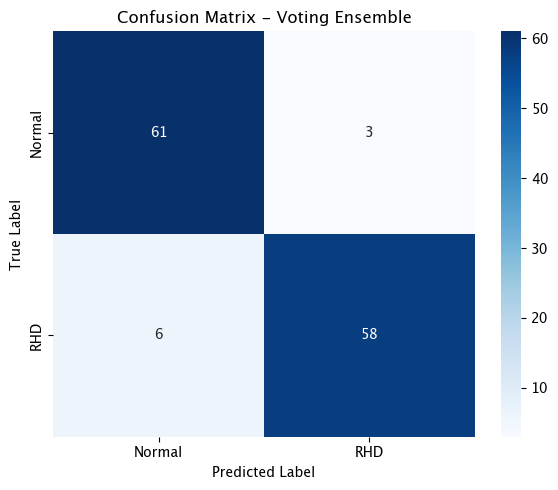

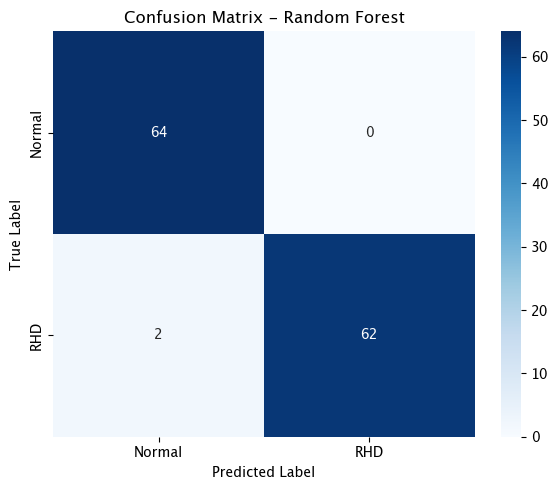

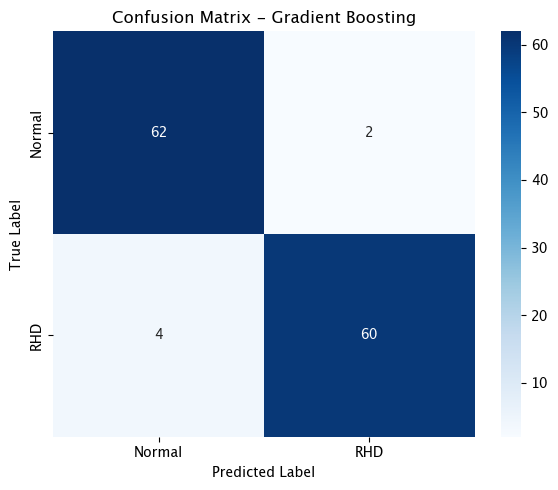

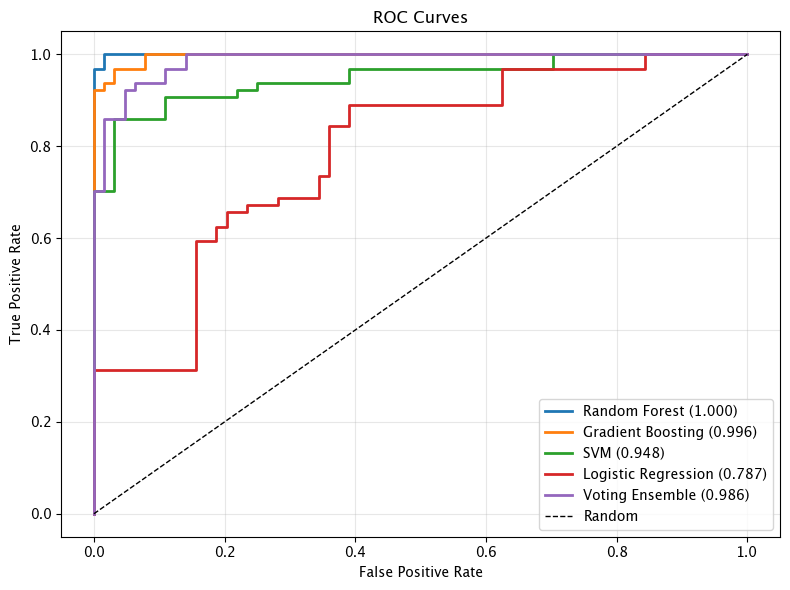


TRAINING COMPLETE!

✅ Results saved to: ../models/mitral_classifier_v4

📊 Model Comparison:
              Model  Accuracy  Precision   Recall       F1      AUC
      Random Forest  0.984375   1.000000 0.968750 0.984127 0.999512
  Gradient Boosting  0.953125   0.967742 0.937500 0.952381 0.996338
    Voting Ensemble  0.929688   0.950820 0.906250 0.928000 0.985840
                SVM  0.890625   0.916667 0.859375 0.887097 0.948486
Logistic Regression  0.718750   0.750000 0.656250 0.700000 0.786865

💾 Best model (Random Forest) saved to: ../models/mitral_classifier_v4/best_model.pkl


In [1]:
# model_training_v4_optimized.ipynb - Optimized Feature Extraction
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import warnings
import time
from tqdm import tqdm
warnings.filterwarnings('ignore')

# Configuration
BALANCED_PATH = '../data/balanced/mitral_valve'
OUTPUT_PATH = '../models/mitral_classifier_v4'
os.makedirs(OUTPUT_PATH, exist_ok=True)

class HeartSoundFeatureExtractor:
    """Optimized feature extractor for heart sounds"""
    
    def __init__(self, sr=4000):
        self.sr = sr
        
    def extract_features(self, file_path):
        """Extract features from audio file - optimized version"""
        try:
            # Load audio (already bandpass filtered)
            signal, _ = librosa.load(file_path, sr=self.sr, duration=10.0)  # Limit duration
            
            if len(signal) < 1000:  # Too short
                return None
            
            features = {}
            
            # 1. Basic statistics (fast)
            features['mean'] = np.mean(signal)
            features['std'] = np.std(signal)
            features['rms'] = np.sqrt(np.mean(signal**2))
            features['peak'] = np.max(np.abs(signal))
            
            # 2. Zero crossing rate (fast)
            zcr = librosa.feature.zero_crossing_rate(signal)[0]
            features['zcr_mean'] = np.mean(zcr)
            features['zcr_std'] = np.std(zcr)
            
            # 3. Spectral features (medium)
            try:
                spec = np.abs(librosa.stft(signal, n_fft=1024, hop_length=256))
                spec_db = librosa.amplitude_to_db(spec, ref=np.max)
                
                features['spec_mean'] = np.mean(spec_db)
                features['spec_std'] = np.std(spec_db)
                features['spec_max'] = np.max(spec_db)
                
                # Spectral centroid
                freqs = librosa.fft_frequencies(sr=self.sr, n_fft=1024)
                centroid = np.sum(freqs[:, None] * spec, axis=0) / (np.sum(spec, axis=0) + 1e-8)
                features['spec_centroid'] = np.mean(centroid)
                features['spec_centroid_std'] = np.std(centroid)
                
                # Spectral bandwidth
                bandwidth = np.sqrt(np.sum((freqs[:, None] - centroid[None, :])**2 * spec, axis=0) / (np.sum(spec, axis=0) + 1e-8))
                features['spec_bandwidth'] = np.mean(bandwidth)
                
                # Spectral rolloff (85%)
                cumsum = np.cumsum(spec, axis=0)
                rolloff = np.argmax(cumsum >= 0.85 * cumsum[-1, :], axis=0)
                features['spec_rolloff'] = np.mean(rolloff) * self.sr / 1024
            except:
                features['spec_mean'] = 0
                features['spec_std'] = 0
                features['spec_max'] = 0
                features['spec_centroid'] = 0
                features['spec_centroid_std'] = 0
                features['spec_bandwidth'] = 0
                features['spec_rolloff'] = 0
            
            # 4. MFCC features (medium, but only a few)
            try:
                mfccs = librosa.feature.mfcc(y=signal, sr=self.sr, n_mfcc=13, n_fft=1024)
                for i in range(13):
                    features[f'mfcc_{i}'] = np.mean(mfccs[i])
                    features[f'mfcc_{i}_std'] = np.std(mfccs[i])
            except:
                for i in range(13):
                    features[f'mfcc_{i}'] = 0
                    features[f'mfcc_{i}_std'] = 0
            
            # 5. Mel spectrogram summary (fast)
            try:
                mel_spec = librosa.feature.melspectrogram(y=signal, sr=self.sr, n_mels=64, n_fft=1024)
                mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
                features['mel_mean'] = np.mean(mel_spec_db)
                features['mel_std'] = np.std(mel_spec_db)
                features['mel_max'] = np.max(mel_spec_db)
                features['mel_energy'] = np.sum(mel_spec_db)
            except:
                features['mel_mean'] = 0
                features['mel_std'] = 0
                features['mel_max'] = 0
                features['mel_energy'] = 0
            
            # 6. Tempo
            try:
                tempo, _ = librosa.beat.beat_track(y=signal, sr=self.sr)
                features['tempo'] = float(tempo) if isinstance(tempo, np.ndarray) else tempo
            except:
                features['tempo'] = 0
            
            # 7. Envelope features
            envelope = np.abs(signal)
            envelope_smooth = np.convolve(envelope, np.ones(50)/50, mode='same')
            features['env_mean'] = np.mean(envelope_smooth)
            features['env_std'] = np.std(envelope_smooth)
            features['env_peak'] = np.max(envelope_smooth)
            features['env_peak_ratio'] = features['env_peak'] / (features['env_mean'] + 1e-8)
            
            # 8. Energy ratios (different frequency bands)
            try:
                # Split signal into frequency bands
                fft = np.fft.rfft(signal)
                freqs = np.fft.rfftfreq(len(signal), 1/self.sr)
                power = np.abs(fft)**2
                
                # Define frequency bands (in Hz)
                bands = [(20, 80), (80, 200), (200, 400)]
                total_power = np.sum(power) + 1e-8
                
                for i, (low, high) in enumerate(bands):
                    mask = (freqs >= low) & (freqs < high)
                    features[f'band_{i}_power'] = np.sum(power[mask]) / total_power
            except:
                for i in range(3):
                    features[f'band_{i}_power'] = 0
            
            return features
            
        except Exception as e:
            return None

def extract_features_batch(df, label_col='label', batch_size=100):
    """Extract features in batches with progress bar"""
    
    feature_extractor = HeartSoundFeatureExtractor()
    all_features = []
    all_labels = []
    skipped = 0
    
    # Get all file paths first
    file_paths = []
    labels = []
    
    for idx, row in df.iterrows():
        patient_id = row['patient_id']
        label = row['label']
        
        # Find file
        file_path = None
        for path in [
            os.path.join(BALANCED_PATH, label, f"{patient_id}.wav"),
            os.path.join(BALANCED_PATH, 'augmented', label, f"{patient_id}.wav")
        ]:
            if os.path.exists(path):
                file_path = path
                break
        
        if file_path is None:
            # Try to find in augmented folder
            aug_dir = os.path.join(BALANCED_PATH, 'augmented', label)
            if os.path.exists(aug_dir):
                for f in os.listdir(aug_dir):
                    if f.startswith(str(patient_id)):
                        file_path = os.path.join(aug_dir, f)
                        break
        
        if file_path is None:
            skipped += 1
            continue
        
        file_paths.append(file_path)
        labels.append(1 if label == 'rhd' else 0)
    
    # Extract features with progress bar
    print(f"  Processing {len(file_paths)} files...")
    
    for i in tqdm(range(0, len(file_paths)), desc="  Extracting features"):
        features = feature_extractor.extract_features(file_paths[i])
        if features is not None:
            all_features.append(features)
            all_labels.append(labels[i])
        else:
            skipped += 1
    
    if skipped > 0:
        print(f"  Skipped {skipped} samples")
    
    if len(all_features) == 0:
        return pd.DataFrame()
    
    feature_df = pd.DataFrame(all_features)
    feature_df['label'] = all_labels
    
    return feature_df

def create_data_splits():
    """Create train/val/test splits"""
    
    combined_df = pd.read_csv(os.path.join(BALANCED_PATH, 'combined_summary.csv'))
    
    # Separate original and augmented
    original_df = combined_df[~combined_df['patient_id'].astype(str).str.contains('_', na=False)].copy()
    augmented_df = combined_df[combined_df['patient_id'].astype(str).str.contains('_', na=False)].copy()
    
    print(f"Original samples: {len(original_df)}")
    print(f"Augmented samples: {len(augmented_df)}")
    
    # Split original patients stratified by label
    patients = original_df['patient_id'].unique()
    labels = []
    for patient in patients:
        label = original_df[original_df['patient_id'] == patient]['label'].iloc[0]
        labels.append(label)
    
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(sss.split(patients, labels))
    train_patients = patients[train_idx]
    test_patients = patients[test_idx]
    
    test_labels = [labels[i] for i in test_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
    val_idx, test_final_idx = next(sss2.split(test_patients, test_labels))
    val_patients = test_patients[val_idx]
    test_patients = test_patients[test_final_idx]
    
    train_df = original_df[original_df['patient_id'].isin(train_patients)]
    val_df = original_df[original_df['patient_id'].isin(val_patients)]
    test_df = original_df[original_df['patient_id'].isin(test_patients)]
    
    # Add augmented data to training
    train_df = pd.concat([train_df, augmented_df], ignore_index=True)
    train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples: {len(val_df)}")
    print(f"Test samples: {len(test_df)}")
    
    return train_df, val_df, test_df

def train_ensemble_models(X_train, y_train, X_test, y_test):
    """Train an ensemble of models"""
    
    print("\nScaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Create models
    models = {
        'Random Forest': RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            min_samples_split=5,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=50,
            learning_rate=0.1,
            max_depth=4,
            random_state=42
        ),
        'SVM': SVC(
            kernel='rbf', 
            C=1.0, 
            probability=True,
            class_weight='balanced',
            random_state=42
        ),
        'Logistic Regression': LogisticRegression(
            C=1.0,
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        )
    }
    
    results = {}
    
    for name, model in models.items():
        print(f"\nTraining {name}...")
        start_time = time.time()
        model.fit(X_train_scaled, y_train)
        train_time = time.time() - start_time
        
        # Evaluate
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
        
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        
        if y_proba is not None:
            auc = roc_auc_score(y_test, y_proba)
        else:
            auc = 0
        
        results[name] = {
            'model': model,
            'scaler': scaler,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc,
            'y_pred': y_pred,
            'y_proba': y_proba,
            'train_time': train_time
        }
        
        print(f"  ✓ Accuracy: {accuracy:.4f} | F1: {f1:.4f} | AUC: {auc:.4f} ({train_time:.1f}s)")
    
    # Voting Ensemble
    print("\nCreating Voting Ensemble...")
    voting_clf = VotingClassifier(
        estimators=[('rf', models['Random Forest']), 
                   ('gb', models['Gradient Boosting']), 
                   ('svm', models['SVM']), 
                   ('lr', models['Logistic Regression'])],
        voting='soft'
    )
    voting_clf.fit(X_train_scaled, y_train)
    
    y_pred = voting_clf.predict(X_test_scaled)
    y_proba = voting_clf.predict_proba(X_test_scaled)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    
    results['Voting Ensemble'] = {
        'model': voting_clf,
        'scaler': scaler,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'train_time': 0
    }
    
    print(f"  ✓ Accuracy: {accuracy:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    
    return results

def plot_results(results, y_test):
    """Plot results"""
    
    # Confusion matrices for top models
    top_models = ['Voting Ensemble', 'Random Forest', 'Gradient Boosting']
    for name in top_models:
        if name in results:
            cm = confusion_matrix(y_test, results[name]['y_pred'])
            plt.figure(figsize=(6, 5))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                       xticklabels=['Normal', 'RHD'],
                       yticklabels=['Normal', 'RHD'])
            plt.title(f'Confusion Matrix - {name}', fontsize=12, fontweight='bold')
            plt.ylabel('True Label')
            plt.xlabel('Predicted Label')
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_PATH, f'confusion_matrix_{name.replace(" ", "_")}.png'), 
                       dpi=150, bbox_inches='tight')
            plt.show()
    
    # ROC curves
    plt.figure(figsize=(8, 6))
    for name, result in results.items():
        if result['y_proba'] is not None:
            fpr, tpr, _ = roc_curve(y_test, result['y_proba'])
            plt.plot(fpr, tpr, label=f'{name} ({result["auc"]:.3f})', linewidth=2)
    
    plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves', fontsize=12, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_PATH, 'roc_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    print("="*60)
    print("HEART SOUND CLASSIFICATION - OPTIMIZED FEATURE EXTRACTION")
    print("="*60)
    
    # Create data splits
    print("\n1. Creating data splits...")
    train_df, val_df, test_df = create_data_splits()
    
    # Extract features (batched with progress bar)
    print("\n2. Extracting features from audio...")
    print("  This may take a few minutes for 4862 samples...")
    start_time = time.time()
    
    train_features = extract_features_batch(train_df)
    print(f"  ✓ Training features: {len(train_features)} samples, {len(train_features.columns)-1} features")
    
    val_features = extract_features_batch(val_df)
    print(f"  ✓ Validation features: {len(val_features)} samples")
    
    test_features = extract_features_batch(test_df)
    print(f"  ✓ Test features: {len(test_features)} samples")
    
    feature_time = time.time() - start_time
    print(f"  ⏱ Feature extraction took {feature_time/60:.1f} minutes")
    
    # Prepare data
    if len(train_features) == 0 or len(test_features) == 0:
        print("\n❌ No features extracted!")
        exit()
    
    feature_cols = [col for col in train_features.columns if col != 'label']
    X_train = train_features[feature_cols].fillna(0)
    y_train = train_features['label']
    X_test = test_features[feature_cols].fillna(0)
    y_test = test_features['label']
    
    print(f"\nFeature shape: {X_train.shape[1]} features")
    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")
    
    # Train models
    print("\n3. Training ensemble models...")
    results = train_ensemble_models(X_train, y_train, X_test, y_test)
    
    # Plot results
    print("\n4. Plotting results...")
    plot_results(results, y_test)
    
    # Save results
    results_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Accuracy': [results[m]['accuracy'] for m in results],
        'Precision': [results[m]['precision'] for m in results],
        'Recall': [results[m]['recall'] for m in results],
        'F1': [results[m]['f1'] for m in results],
        'AUC': [results[m]['auc'] for m in results]
    })
    results_df = results_df.sort_values('F1', ascending=False)
    results_df.to_csv(os.path.join(OUTPUT_PATH, 'model_comparison.csv'), index=False)
    
    print("\n" + "="*60)
    print("TRAINING COMPLETE!")
    print("="*60)
    print("\n✅ Results saved to:", OUTPUT_PATH)
    print("\n📊 Model Comparison:")
    print(results_df.to_string(index=False))
    
    # Save the best model
    best_model_name = results_df.iloc[0]['Model']
    best_model = results[best_model_name]['model']
    best_scaler = results[best_model_name]['scaler']
    
    import joblib
    joblib.dump(best_model, os.path.join(OUTPUT_PATH, 'best_model.pkl'))
    joblib.dump(best_scaler, os.path.join(OUTPUT_PATH, 'scaler.pkl'))
    print(f"\n💾 Best model ({best_model_name}) saved to: {OUTPUT_PATH}/best_model.pkl")